# Fuzzy Logic Penentuan Risiko Diabetes Berdasarkan Usia dan Berat Badan 
Penentuan risiko diabetes ini menggunakan metode logika fuzzy dengan dua variabel input yaitu usia dan berat badan yang dibagi menjadi beberapa tahapan:

- **Fuzzification**  
  Nilai usia dan berat badan dimasukkan ke dalam sistem sebagai data awal yang bersifat tegas (crisp). Nilai crisp diubah menjadi degree of membership pada beberapa himpunan fuzzy untuk variabel usia dan berat badan.

- **Inference / Rule Evaluation**  
  Hasil fuzzification berupa nilai keanggotaan yang digunakan sebagai input pada proses inferensi (Fuzzy input). Sistem menggunakan aturan IF–THEN untuk menentukan hubungan antara usia dan berat badan terhadap tingkat risiko diabetes.

- **Defuzzification**  
  Hasil dari proses inferensi berupa keluaran dalam bentuk fuzzy yang menunjukkan kategori risiko (fuzzy output) yang kemudian diubah menjadi nilai crisp. Pada penelitian ini digunakan tiga metode defuzzification yang akan dibandingkan, yaitu:
  - **Max Method**
  - **Mamdani**
  - **Sugeno** 
  
  Nilai akhir yang dihasilkan sistem berupa tingkat risiko diabetes dalam bentuk nilai yang dapat diinterpretasikan secara langsung.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Crisp Input

Data awal dimasukkan ke dalam sistem dalam bentuk nilai crisp (numerik). Pada contoh ini digunakan dua variabel input yaitu **usia** dan **berat badan** dari beberapa pasien. Data yang digunakan merupakan data dummy yang dibuat sebagai contoh untuk proses pengujian sistem. Data tersebut kemudian digunakan sebagai dasar pada tahap fuzzification dalam sistem fuzzy.

In [2]:
data = pd.DataFrame({
    "Pasien": ["P1","P2","P3","P4","P5","P6","P7","P8"],
    "Usia":   [44, 43, 39, 64, 69, 45, 70, 40],
    "Berat":  [49, 54, 64, 84, 109, 55, 119, 42]
})
data

,Pasien,Usia,Berat
0,P1,44,49
1,P2,43,54
2,P3,39,64
3,P4,64,84
4,P5,69,109
5,P6,45,55
6,P7,70,119
7,P8,40,42


## Membership Function

Pada sistem fuzzy, membership function digunakan untuk menentukan derajat keanggotaan suatu nilai pada himpunan fuzzy. Dalam implementasi ini digunakan dua jenis fungsi keanggotaan, yaitu triangular membership function (trimf) dan trapezoidal membership function (trapmf).

- **trimf (Triangular Membership Function)**  
  Fungsi ini membentuk kurva segitiga yang ditentukan oleh tiga parameter (a, b, c). Nilai keanggotaan meningkat secara linear dari a ke b, mencapai nilai maksimum 1 di titik b, kemudian menurun secara linear dari b ke c.

- **trapmf (Trapezoidal Membership Function)**  
  Fungsi ini membentuk kurva trapesium yang ditentukan oleh empat parameter (a, b, c, d). Nilai keanggotaan meningkat dari a ke b, bernilai 1 pada interval b hingga c, kemudian menurun dari c ke d.


In [3]:
def trimf(x, a, b, c):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    y[x == b] = 1.0

    if c != b:
        idx = (b < x) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)

    return np.clip(y, 0, 1)


def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)
    else:
        y[(x >= a) & (x <= b)] = 1.0

    y[(x >= b) & (x <= c)] = 1.0

    if d != c:
        idx = (c < x) & (x < d)
        y[idx] = (d - x[idx]) / (d - c)
    else:
        y[(x >= c) & (x <= d)] = 1.0

    return np.clip(y, 0, 1)

## Definisi Variabel Fuzzy

Pada tahap ini ditentukan domain nilai dan fungsi keanggotaan untuk setiap variabel yang digunakan dalam sistem fuzzy, yaitu **usia**, **berat badan**, dan **risiko diabetes**.

- **Usia (19–80 tahun)**  
  Variabel usia dibagi menjadi tiga kategori fuzzy:
  - young : 19 – 39 tahun  
  - middle : 45 – 64 tahun  
  - old : 70 – 80 tahun  
  Ketiga kategori dimodelkan menggunakan trapezoidal.

- **Berat Badan (35–120 kg)**  
  Variabel berat badan dibagi menjadi lima kategori:
  - sangat ringan : 35 – 42 kg  
  - ringan : 50 – 55 kg  
  - sedang : 65 – 72 kg  
  - berat : 85 – 95 kg  
  - sangat berat : 110 – 120 kg  
  Semua kategori menggunakan trapezoidal.

- **Risiko Diabetes (0–100)**  
  Variabel output risiko dibagi menjadi tiga kategori:
  - risiko kecil : 0 – 40  
  - risiko sedang : 30 – 70  
  - risiko tinggi : 60 – 100  

  Kategori kecil dan tinggi menggunakan trapezoidal, sedangkan kategori sedang menggunakan triangular.

In [4]:
usia = np.linspace(19, 100, 1000)
berat_badan = np.linspace(35, 120, 1000)
risiko = np.linspace(0, 100, 1000)

young  = trapmf(usia, 19, 19, 39, 45)
middle = trapmf(usia, 40, 45, 64, 70)
old    = trapmf(usia, 65, 70, 100, 100)

bb_sangat_ringan = trapmf(berat_badan, 35, 35, 42, 50)
bb_ringan        = trapmf(berat_badan, 42, 50, 55, 65)
bb_sedang        = trapmf(berat_badan, 55, 65, 72, 85)
bb_berat         = trapmf(berat_badan, 72, 85, 95, 110)
bb_sangat_berat  = trapmf(berat_badan, 95, 110, 120, 120)

risiko_kecil  = trapmf(risiko, 0, 0, 20, 40)
risiko_sedang = trimf(risiko, 30, 50, 70)
risiko_tinggi = trapmf(risiko, 60, 80, 100, 100)

## Visualisasi Membership Function

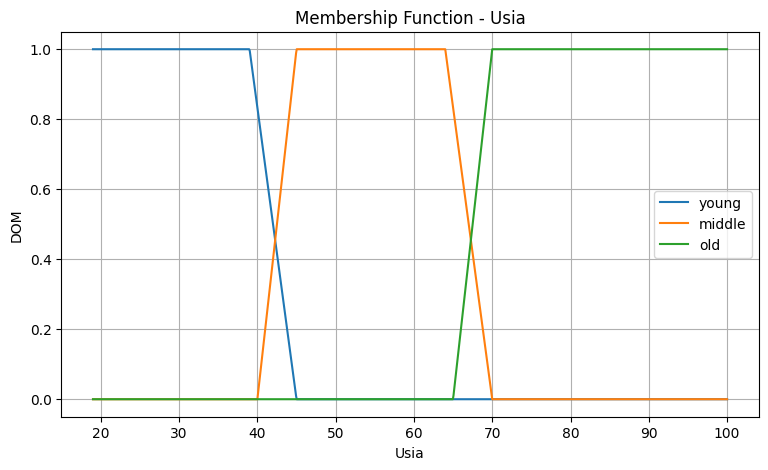

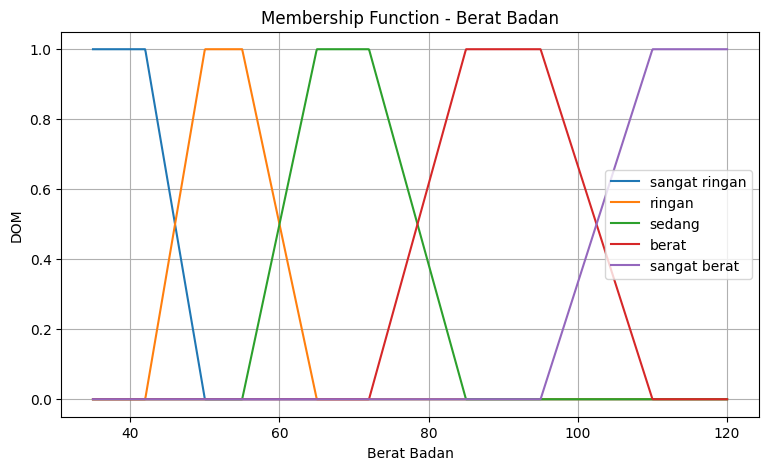

In [5]:
plt.figure()
plt.plot(usia, young, label="young")
plt.plot(usia, middle, label="middle")
plt.plot(usia, old, label="old")
plt.title("Membership Function - Usia")
plt.xlabel("Usia")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(berat_badan, bb_sangat_ringan, label="sangat ringan")
plt.plot(berat_badan, bb_ringan, label="ringan")
plt.plot(berat_badan, bb_sedang, label="sedang")
plt.plot(berat_badan, bb_berat, label="berat")
plt.plot(berat_badan, bb_sangat_berat, label="sangat berat")
plt.title("Membership Function - Berat Badan")
plt.xlabel("Berat Badan")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()

# plt.figure()
# plt.plot(risiko, risiko_kecil, label="kecil")
# plt.plot(risiko, risiko_sedang, label="sedang")
# plt.plot(risiko, risiko_tinggi, label="tinggi")
# plt.title("Membership Function - Risiko")
# plt.xlabel("Skor Risiko")
# plt.ylabel("DOM")
# plt.legend()
# plt.grid(True)
# plt.show()

## Rule Base (IF–THEN)

Aturan fuzzy yang digunakan adalah sebagai berikut:

1. IF **usia = young** AND **berat badan = sangat_ringan** THEN **risiko = kecil**  
2. IF **usia = young** AND **berat badan = ringan** THEN **risiko = kecil**  
3. IF **usia = young** AND **berat badan = sedang** THEN **risiko = sedang**  
4. IF **usia = young** AND **berat badan = berat** THEN **risiko = sedang**  
5. IF **usia = young** AND **berat badan = sangat_berat** THEN **risiko = tinggi**

6. IF **usia = middle** AND **berat badan = sangat_ringan** THEN **risiko = kecil**  
7. IF **usia = middle** AND **berat badan = ringan** THEN **risiko = sedang**  
8. IF **usia = middle** AND **berat badan = sedang** THEN **risiko = sedang**  
9. IF **usia = middle** AND **berat badan = berat** THEN **risiko = tinggi**  
10. IF **usia = middle** AND **berat badan = sangat_berat** THEN **risiko = tinggi**

11. IF **usia = old** AND **berat badan = sangat_ringan** THEN **risiko = sedang**  
12. IF **usia = old** AND **berat badan = ringan** THEN **risiko = sedang**  
13. IF **usia = old** AND **berat badan = sedang** THEN **risiko = tinggi**  
14. IF **usia = old** AND **berat badan = berat** THEN **risiko = tinggi**  
15. IF **usia = old** AND **berat badan = sangat_berat** THEN **risiko = tinggi**

In [6]:
rules = [
    ("young",  "sangat_ringan", "kecil"),
    ("young",  "ringan",        "kecil"),
    ("young",  "sedang",        "sedang"),
    ("young",  "berat",         "sedang"),
    ("young",  "sangat_berat",  "tinggi"),

    ("middle", "sangat_ringan", "kecil"),
    ("middle", "ringan",        "sedang"),
    ("middle", "sedang",        "sedang"),
    ("middle", "berat",         "tinggi"),
    ("middle", "sangat_berat",  "tinggi"),

    ("old",    "sangat_ringan", "sedang"),
    ("old",    "ringan",        "sedang"),
    ("old",    "sedang",        "tinggi"),
    ("old",    "berat",         "tinggi"),
    ("old",    "sangat_berat",  "tinggi"),
]
rules

[('young', 'sangat_ringan', 'kecil'),
 ('young', 'ringan', 'kecil'),
 ('young', 'sedang', 'sedang'),
 ('young', 'berat', 'sedang'),
 ('young', 'sangat_berat', 'tinggi'),
 ('middle', 'sangat_ringan', 'kecil'),
 ('middle', 'ringan', 'sedang'),
 ('middle', 'sedang', 'sedang'),
 ('middle', 'berat', 'tinggi'),
 ('middle', 'sangat_berat', 'tinggi'),
 ('old', 'sangat_ringan', 'sedang'),
 ('old', 'ringan', 'sedang'),
 ('old', 'sedang', 'tinggi'),
 ('old', 'berat', 'tinggi'),
 ('old', 'sangat_berat', 'tinggi')]

## Fuzzification 

In [7]:
def fuzzify(u, b):

    usia_val = {
        "young":  float(trapmf([u], 19, 19, 39, 45)[0]),
        "middle": float(trapmf([u], 40, 45, 64, 70)[0]),
        "old":    float(trapmf([u], 65, 70, 100, 100)[0]),
    }

    berat_val = {
        "sangat_ringan": float(trapmf([b], 35, 35, 42, 50)[0]),
        "ringan":        float(trapmf([b], 42, 50, 55, 65)[0]),
        "sedang":        float(trapmf([b], 55, 65, 72, 85)[0]),
        "berat":         float(trapmf([b], 72, 85, 95, 110)[0]),
        "sangat_berat":  float(trapmf([b], 95, 110, 120, 120)[0]),
    }

    return usia_val, berat_val

## Inference

In [8]:
def inference(u, b):
    usia_val, berat_val = fuzzify(u, b)

    rows = []
    for age_label, bb_label, out_label in rules:
        alpha = min(usia_val[age_label], berat_val[bb_label])
        rows.append({
            "usia_set": age_label,
            "berat_set": bb_label,
            "output": out_label,
            "alpha": alpha
        })
    return pd.DataFrame(rows)

## Defuzzification - Sugeno

In [9]:
def sugeno(u, b):
    df = inference(u, b).copy()

    z_map = {
        "kecil": 25.0,
        "sedang": 50.0,
        "tinggi": 75.0
    }

    df["z"] = df["output"].map(z_map)

    df["alpha_z"] = df["alpha"] * df["z"]

    denom = df["alpha"].sum()
    if denom == 0:
        return 0.0, df

    crisp = df["alpha_z"].sum() / denom

    return float(crisp), df

## Defuzzification - Max Method

In [10]:
def max_method(u, b):
    df = inference(u, b)

    # agregasi output, ambil alpha terbesar
    agg = df.groupby("output", as_index=False)["alpha"].max()
    label = agg.loc[agg["alpha"].idxmax(), "output"]

    z_map = {
        "kecil": 25.0,
        "sedang": 50.0,
        "tinggi": 75.0
    }
    return float(z_map[label]), df, agg

## Defuzzification - Mamdani

In [11]:
def mamdani(u, b):
    df = inference(u, b)

    alpha_kecil = df.loc[df["output"] == "kecil", "alpha"].max()
    alpha_sedang = df.loc[df["output"] == "sedang", "alpha"].max()
    alpha_tinggi = df.loc[df["output"] == "tinggi", "alpha"].max()

    kecil_cut = np.minimum(alpha_kecil, risiko_kecil)
    sedang_cut = np.minimum(alpha_sedang, risiko_sedang)
    tinggi_cut = np.minimum(alpha_tinggi, risiko_tinggi)

    aggregated = np.maximum(kecil_cut, np.maximum(sedang_cut, tinggi_cut))

    if np.sum(aggregated) == 0:
        return 0.0, df, aggregated

    crisp = np.sum(risiko * aggregated) / np.sum(aggregated)
    return float(crisp), df, aggregated

## Hasil Fuzzification

Pasien:
Pasien    P2
Usia      43
Berat     54
Name: 1, dtype: object

Derajat keanggotaan usia:
young    0.3333
middle   0.6000
old      0.0000
dtype: float64

Derajat keanggotaan berat badan:
sangat_ringan   0.0000
ringan          1.0000
sedang          0.0000
berat           0.0000
sangat_berat    0.0000
dtype: float64


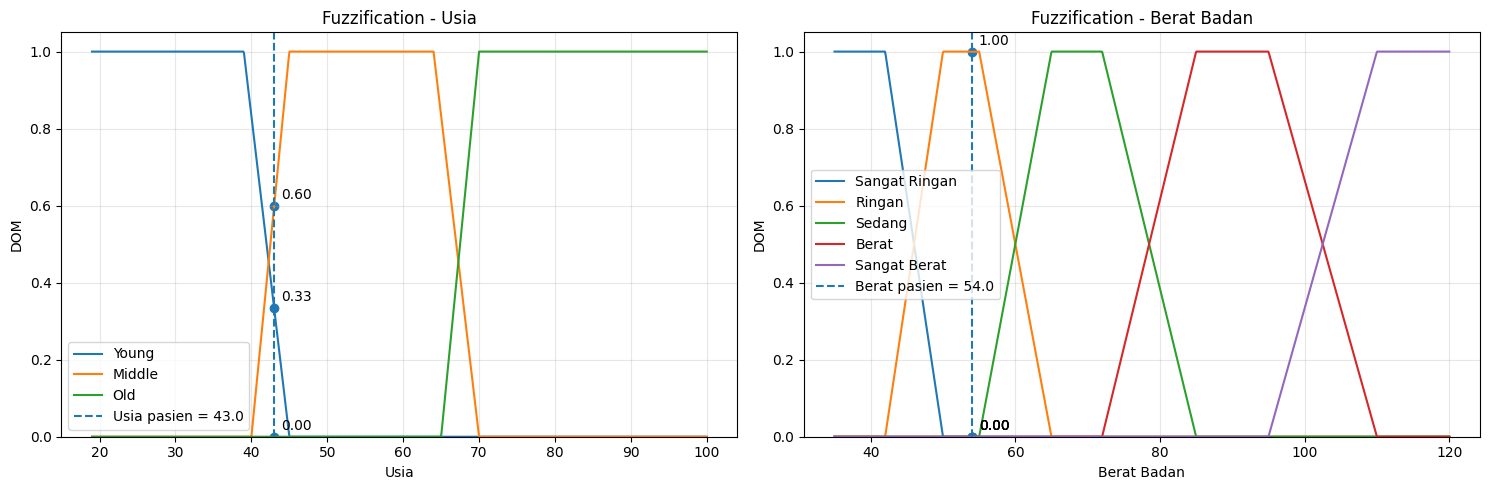

In [12]:
sample = data.iloc[1]   
u = float(sample["Usia"])
b = float(sample["Berat"])

print("Pasien:")
print(sample)

usia_val, berat_val = fuzzify(u, b)

print("\nDerajat keanggotaan usia:")
print(pd.Series(usia_val))

print("\nDerajat keanggotaan berat badan:")
print(pd.Series(berat_val))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MF Usia
axes[0].plot(usia, young, label="Young")
axes[0].plot(usia, middle, label="Middle")
axes[0].plot(usia, old, label="Old")

axes[0].axvline(u, linestyle="--", label=f"Usia pasien = {u:.1f}")

axes[0].scatter([u]*3,
                [usia_val["young"], usia_val["middle"], usia_val["old"]])

axes[0].annotate(f'{usia_val["young"]:.2f}', (u, usia_val["young"]),
                 textcoords="offset points", xytext=(5, 5))
axes[0].annotate(f'{usia_val["middle"]:.2f}', (u, usia_val["middle"]),
                 textcoords="offset points", xytext=(5, 5))
axes[0].annotate(f'{usia_val["old"]:.2f}', (u, usia_val["old"]),
                 textcoords="offset points", xytext=(5, 5))

axes[0].set_title("Fuzzification - Usia")
axes[0].set_xlabel("Usia")
axes[0].set_ylabel("DOM")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MF Berat Badan

axes[1].plot(berat_badan, bb_sangat_ringan, label="Sangat Ringan")
axes[1].plot(berat_badan, bb_ringan, label="Ringan")
axes[1].plot(berat_badan, bb_sedang, label="Sedang")
axes[1].plot(berat_badan, bb_berat, label="Berat")
axes[1].plot(berat_badan, bb_sangat_berat, label="Sangat Berat")

axes[1].axvline(b, linestyle="--", label=f"Berat pasien = {b:.1f}")

axes[1].scatter([b]*5,
                [berat_val["sangat_ringan"],
                 berat_val["ringan"],
                 berat_val["sedang"],
                 berat_val["berat"],
                 berat_val["sangat_berat"]])

axes[1].annotate(f'{berat_val["sangat_ringan"]:.2f}', (b, berat_val["sangat_ringan"]),
                 textcoords="offset points", xytext=(5, 5))
axes[1].annotate(f'{berat_val["ringan"]:.2f}', (b, berat_val["ringan"]),
                 textcoords="offset points", xytext=(5, 5))
axes[1].annotate(f'{berat_val["sedang"]:.2f}', (b, berat_val["sedang"]),
                 textcoords="offset points", xytext=(5, 5))
axes[1].annotate(f'{berat_val["berat"]:.2f}', (b, berat_val["berat"]),
                 textcoords="offset points", xytext=(5, 5))
axes[1].annotate(f'{berat_val["sangat_berat"]:.2f}', (b, berat_val["sangat_berat"]),
                 textcoords="offset points", xytext=(5, 5))

axes[1].set_title("Fuzzification - Berat Badan")
axes[1].set_xlabel("Berat Badan")
axes[1].set_ylabel("DOM")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Hasil Inference / Rules Evaluation

In [13]:
from IPython.display import display

df_inf = inference(u, b)
usia_val, berat_val = fuzzify(u, b)

print("\nHasil inference:")
display(df_inf)

col_usia   = "usia_set"
col_berat  = "berat_set"
col_output = "output"
col_alpha  = "alpha"

usia_order = ["young", "middle", "old"]
berat_order = ["sangat_ringan", "ringan", "sedang", "berat", "sangat_berat"]

df_inf[col_usia] = pd.Categorical(df_inf[col_usia], categories=usia_order, ordered=True)
df_inf[col_berat] = pd.Categorical(df_inf[col_berat], categories=berat_order, ordered=True)

tbl_output = df_inf.pivot_table(
    index=col_usia,
    columns=col_berat,
    values=col_output,
    aggfunc="first"
).reindex(index=usia_order, columns=berat_order)

tbl_alpha = df_inf.pivot_table(
    index=col_usia,
    columns=col_berat,
    values=col_alpha,
    aggfunc="first"
).reindex(index=usia_order, columns=berat_order)

row_labels_eval = []
for k in usia_order:
    mu = usia_val[k]
    if mu > 0:
        row_labels_eval.append(f"{mu:.1f}")
    else:
        row_labels_eval.append(k)

col_labels_eval = []
for k in berat_order:
    mu = berat_val[k]
    if mu > 0:
        col_labels_eval.append(f"{mu:.1f}")
    else:
        col_labels_eval.append(k)

tbl_alpha_show = tbl_alpha.copy()
tbl_alpha_show.index = row_labels_eval
tbl_alpha_show.columns = col_labels_eval

print("Tabel Rules Output:")
display(tbl_output)

print("Tabel Rules Evaluation (MIN):")
display(tbl_alpha_show)


Hasil inference:


,usia_set,berat_set,output,alpha
0,young,sangat_ringan,kecil,0.0000
1,young,ringan,kecil,0.3333
2,young,sedang,sedang,0.0000
3,young,berat,sedang,0.0000
4,young,sangat_berat,tinggi,0.0000
5,middle,sangat_ringan,kecil,0.0000
6,middle,ringan,sedang,0.6000
7,middle,sedang,sedang,0.0000
8,middle,berat,tinggi,0.0000
9,middle,sangat_berat,tinggi,0.0000


Tabel Rules Output:


berat_set,sangat_ringan,ringan,sedang,berat,sangat_berat
usia_set,,,,,
young,kecil,kecil,sedang,sedang,tinggi
middle,kecil,sedang,sedang,tinggi,tinggi
old,sedang,sedang,tinggi,tinggi,tinggi


Tabel Rules Evaluation (MIN):


,sangat_ringan,1.0,sedang,berat,sangat_berat
0.3,0.0000,0.3333,0.0000,0.0000,0.0000
0.6,0.0000,0.6000,0.0000,0.0000,0.0000
old,0.0000,0.0000,0.0000,0.0000,0.0000


## Hasil Defuzzification - Max Method

In [14]:
z_max, df_max, agg_max = max_method(u, b)

print("=== HASIL MAX METHOD ===")
print("Nilai Crisp :", z_max)

print("\n=== Tabel Inference ===")
display(df_max)

print("\n=== Tabel Aggregation ===")
display(agg_max)

=== HASIL MAX METHOD ===
Nilai Crisp : 50.0

=== Tabel Inference ===


,usia_set,berat_set,output,alpha
0,young,sangat_ringan,kecil,0.0000
1,young,ringan,kecil,0.3333
2,young,sedang,sedang,0.0000
3,young,berat,sedang,0.0000
4,young,sangat_berat,tinggi,0.0000
5,middle,sangat_ringan,kecil,0.0000
6,middle,ringan,sedang,0.6000
7,middle,sedang,sedang,0.0000
8,middle,berat,tinggi,0.0000
9,middle,sangat_berat,tinggi,0.0000



=== Tabel Aggregation ===


,output,alpha
0,kecil,0.3333
1,sedang,0.6000
2,tinggi,0.0000


## Hasil Defuzification - Sugeno

In [15]:
z_sugeno, df_sug = sugeno(u, b)

print("=== HASIL SUGENO ===")
print("Nilai Crisp :", z_sugeno)

print("\n=== Tabel Inference Sugeno ===")
display(df_sug)

=== HASIL SUGENO ===
Nilai Crisp : 41.07142857142856

=== Tabel Inference Sugeno ===


,usia_set,berat_set,output,alpha,z,alpha_z
0,young,sangat_ringan,kecil,0.0000,25.0000,0.0000
1,young,ringan,kecil,0.3333,25.0000,8.3333
2,young,sedang,sedang,0.0000,50.0000,0.0000
3,young,berat,sedang,0.0000,50.0000,0.0000
4,young,sangat_berat,tinggi,0.0000,75.0000,0.0000
5,middle,sangat_ringan,kecil,0.0000,25.0000,0.0000
6,middle,ringan,sedang,0.6000,50.0000,30.0000
7,middle,sedang,sedang,0.0000,50.0000,0.0000
8,middle,berat,tinggi,0.0000,75.0000,0.0000
9,middle,sangat_berat,tinggi,0.0000,75.0000,0.0000


## Hasil Defuzzification - Mamdani

In [16]:
z_mamdani, df_mam, agg_mam = mamdani(u, b)

print("=== HASIL MAMDANI ===")
print("Nilai Crisp :", z_mamdani)

print("\n=== Tabel Inference ===")
display(df_mam)


=== HASIL MAMDANI ===
Nilai Crisp : 36.73914869819447

=== Tabel Inference ===


,usia_set,berat_set,output,alpha
0,young,sangat_ringan,kecil,0.0000
1,young,ringan,kecil,0.3333
2,young,sedang,sedang,0.0000
3,young,berat,sedang,0.0000
4,young,sangat_berat,tinggi,0.0000
5,middle,sangat_ringan,kecil,0.0000
6,middle,ringan,sedang,0.6000
7,middle,sedang,sedang,0.0000
8,middle,berat,tinggi,0.0000
9,middle,sangat_berat,tinggi,0.0000


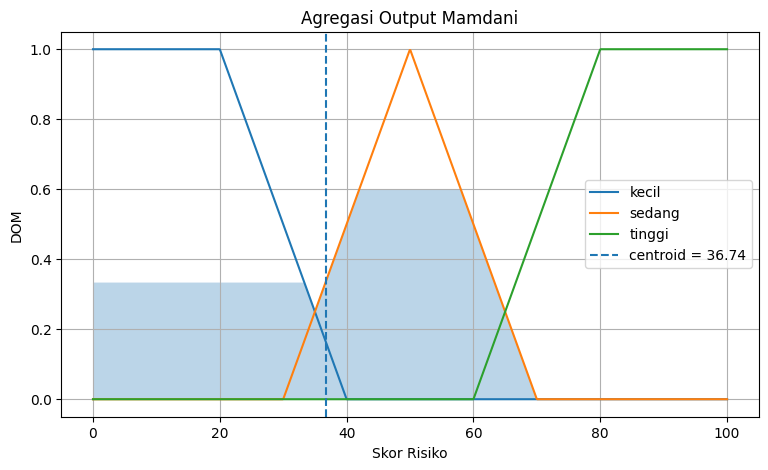

In [17]:
plt.figure()
plt.plot(risiko, risiko_kecil, label="kecil")
plt.plot(risiko, risiko_sedang, label="sedang")
plt.plot(risiko, risiko_tinggi, label="tinggi")
plt.fill_between(risiko, 0, agg_mam, alpha=0.3)
plt.axvline(z_mamdani, linestyle="--", label=f"centroid = {z_mamdani:.2f}")
plt.title("Agregasi Output Mamdani")
plt.xlabel("Skor Risiko")
plt.ylabel("DOM")
plt.legend()
plt.grid(True)
plt.show()

## Perbandingan Hasil 3 Metode Defuzzification

In [18]:
rows = []
for _, r in data.iterrows():
    u = float(r["Usia"])
    b = float(r["Berat"])

    z_max, _, _ = max_method(u, b)
    z_sug, _ = sugeno(u, b)
    z_mam, _, _ = mamdani(u, b)

    rows.append({
        "Pasien": r["Pasien"],
        "Usia": u,
        "Berat": b,
        "Max": z_max,
        "Sugeno": z_sug,
        "Mamdani": z_mam,
    })

result = pd.DataFrame(rows)
result

,Pasien,Usia,Berat,Max,Sugeno,Mamdani
0,P1,44.0000,49.0000,50.0000,41.4384,42.6218
1,P2,43.0000,54.0000,50.0000,41.0714,36.7391
2,P3,39.0000,64.0000,50.0000,47.5000,45.3205
3,P4,64.0000,84.0000,75.0000,73.0769,81.2976
4,P5,69.0000,109.0000,75.0000,75.0000,83.6922
5,P6,45.0000,55.0000,50.0000,50.0000,50.0000
6,P7,70.0000,119.0000,75.0000,75.0000,84.4704
7,P8,40.0000,42.0000,25.0000,25.0000,16.1733


## Visualisasi Perbandingan

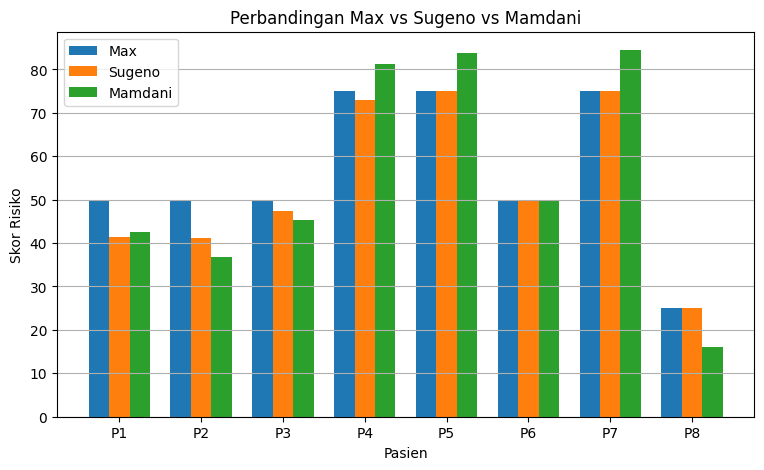

In [19]:
x = np.arange(len(result))
w = 0.25

plt.figure()
plt.bar(x - w, result["Max"], width=w, label="Max")
plt.bar(x, result["Sugeno"], width=w, label="Sugeno")
plt.bar(x + w, result["Mamdani"], width=w, label="Mamdani")

plt.xticks(x, result["Pasien"])
plt.xlabel("Pasien")
plt.ylabel("Skor Risiko")
plt.title("Perbandingan Max vs Sugeno vs Mamdani")
plt.legend()
plt.grid(True, axis="y")
plt.show()